# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier

# LOAD DATASET

In [2]:

print("STEP 1: LOADING DATASET")
df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

print("\nDataset Loaded Successfully")
print("Shape of Dataset:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

STEP 1: LOADING DATASET

Dataset Loaded Successfully
Shape of Dataset: (541909, 8)

First 5 Rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


# EXPLORATORY DATA ANALYSIS (EDA)

In [3]:

print("STEP 2: EXPLORATORY DATA ANALYSIS")

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

print("\nTop 10 Countries:")
print(df["Country"].value_counts().head(10))

print("\nTop 10 Most Purchased Products:")
print(df["Description"].value_counts().head(10))


STEP 2: EXPLORATORY DATA ANALYSIS

Column Names:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country       

# EDA VISUALIZATIONS

EDA VISUALIZATIONS


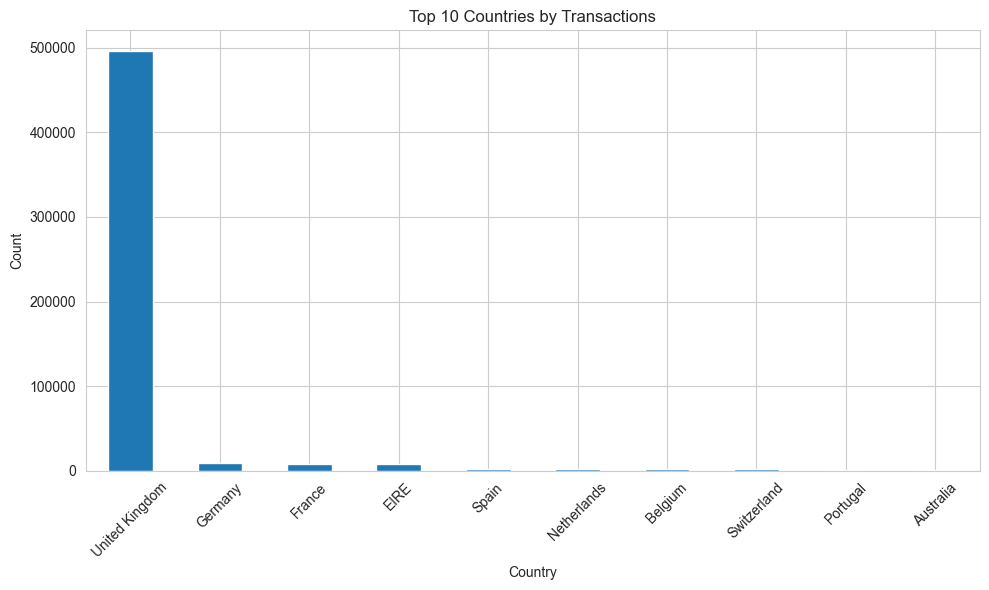

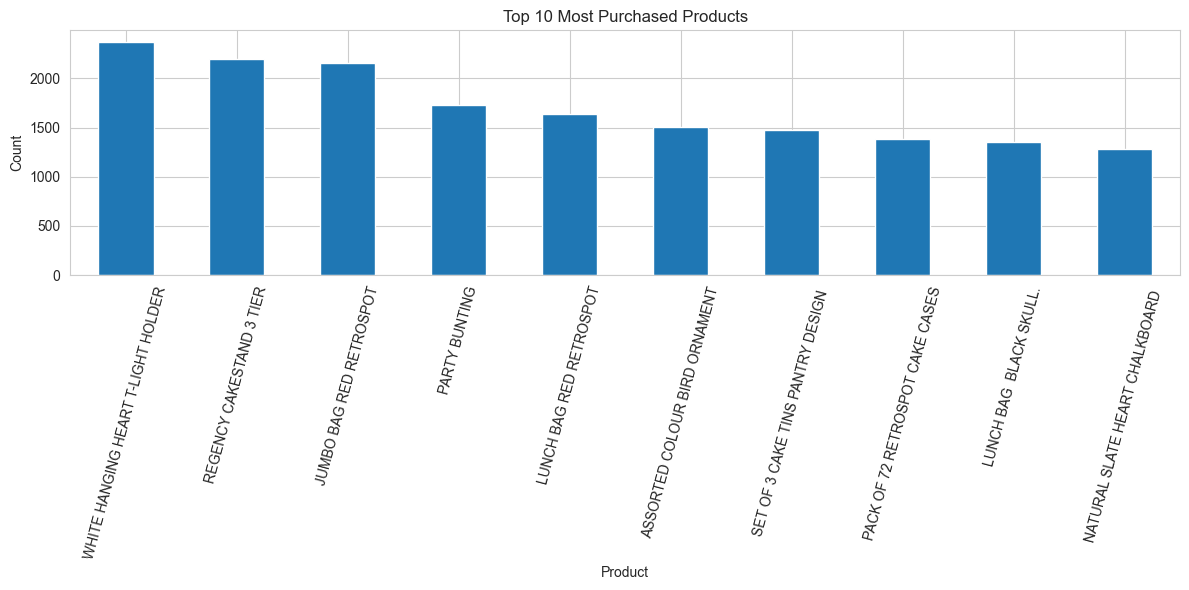

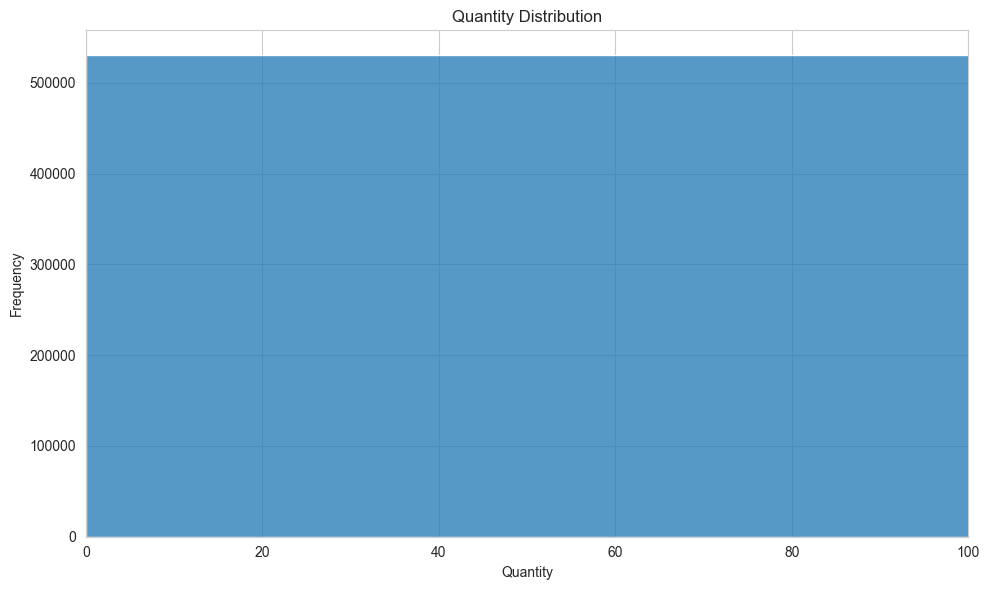

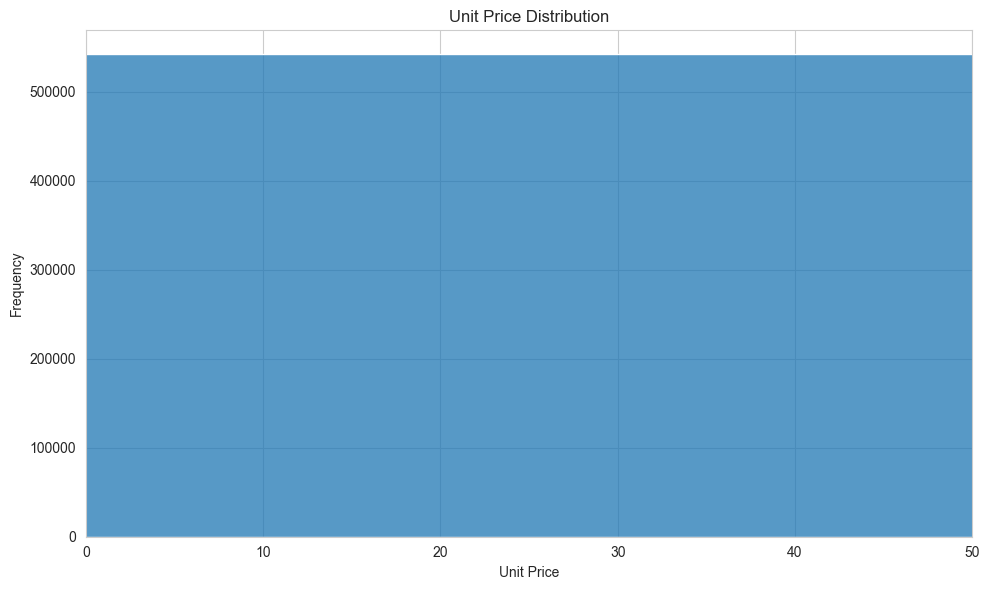

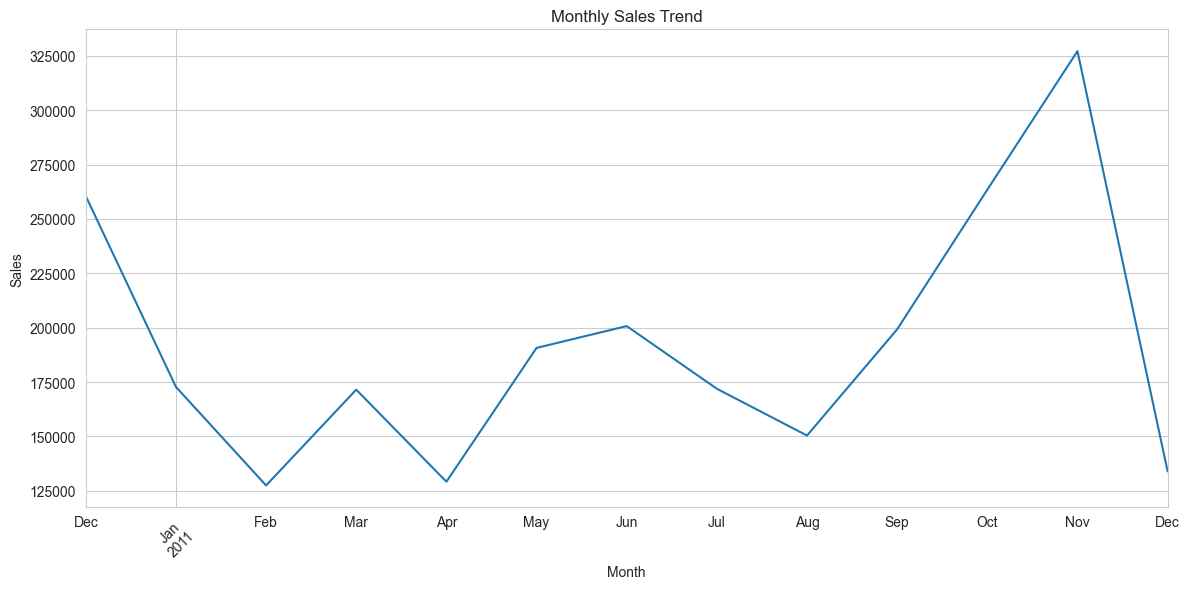

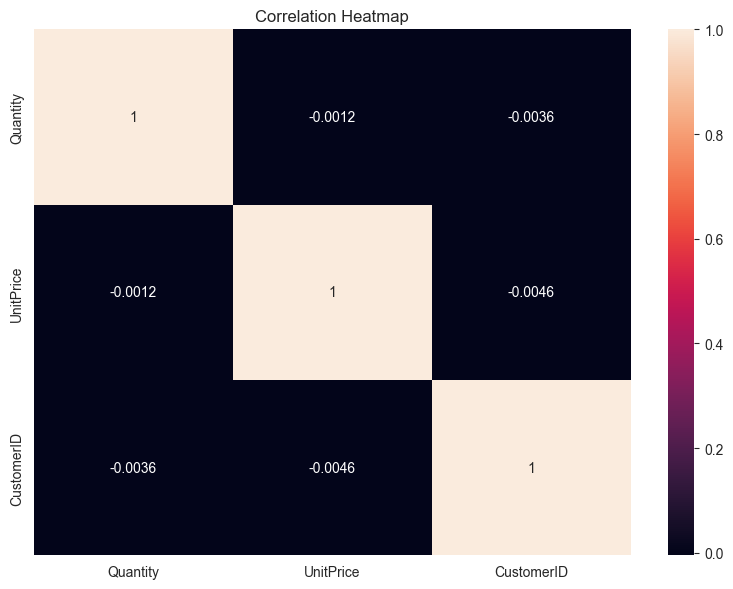

In [4]:

print("EDA VISUALIZATIONS")

sns.set_style("whitegrid")

# 1. Top 10 Countries by Transactions

plt.figure(figsize=(10, 6))
df["Country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries by Transactions")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2. Top 10 Most Purchased Products

plt.figure(figsize=(12, 6))
df["Description"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Purchased Products")
plt.xlabel("Product")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


# 3. Quantity Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Quantity"],
    bins=50
)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


# 4. Unit Price Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    df["UnitPrice"],
    bins=50
)

plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.xlim(0, 50)
plt.tight_layout()
plt.show()


# 5. Monthly Sales Trend

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = df.groupby("Month")["UnitPrice"].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 6. Correlation Heatmap

plt.figure(figsize=(8, 6))

numeric_df = df[
    ["Quantity", "UnitPrice", "CustomerID"]
]

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# DATA CLEANING

In [5]:

print("DATA CLEANING")

# Remove missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Convert CustomerID to int
df["CustomerID"] = df["CustomerID"].astype(int)

# Remove cancelled invoices
df = df[
    ~df["InvoiceNo"].astype(str).str.startswith("C")
]

# Remove invalid quantity
df = df[df["Quantity"] > 0]

# Remove invalid unit price
df = df[df["UnitPrice"] > 0]

# Convert InvoiceDate
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print("\nCleaned Dataset Shape:", df.shape)

print("\nCleaned Data Sample:")
print(df.head())

DATA CLEANING

Cleaned Dataset Shape: (397884, 10)

Cleaned Data Sample:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country    Month  \
0 2010-12-01 08:26:00       2.55       17850  United Kingdom  2010-12   
1 2010-12-01 08:26:00       3.39       17850  United Kingdom  2010-12   
2 2010-12-01 08:26:00       2.75       17850  United Kingdom  2010-12   
3 2010-12-01 08:26:00       3.39       17850  United Kingdom  2010-12   
4 2010-12-01 08:26:00       3.39       17850  United Kingdom  2010-12   

   TotalPrice  
0       15.30  
1       20.34  
2      

# RFM ANALYSIS + FEATURE ENGINEERING

In [6]:

print("STEP 4: RFM ANALYSIS")

latest_date = df["InvoiceDate"].max()

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": [
        lambda x: (latest_date - x.max()).days,   # Recency
        lambda x: (x.max() - x.min()).days        # Customer Lifetime
    ],
    "InvoiceNo": "nunique",                       # Frequency
    "TotalPrice": ["sum", "mean"],                # Monetary + AvgOrderValue
    "Quantity": "mean",                           # AvgQuantity
    "StockCode": "nunique"                        # UniqueProducts
})

rfm.columns = [
    "Recency",
    "CustomerLifetime",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "AvgQuantity",
    "UniqueProducts"
]

rfm = rfm.reset_index()
rfm.set_index("CustomerID", inplace=True)

print("\nRFM Created Successfully")

print("\nFirst 10 Rows:")
print(rfm.head(10))

STEP 4: RFM ANALYSIS

RFM Created Successfully

First 10 Rows:
            Recency  CustomerLifetime  Frequency  Monetary  AvgOrderValue  \
CustomerID                                                                  
12346           325                 0          1  77183.60   77183.600000   
12347             1               365          7   4310.00      23.681319   
12348            74               282          4   1797.24      57.975484   
12349            18                 0          1   1757.55      24.076027   
12350           309                 0          1    334.40      19.670588   
12352            35               260          8   2506.04      29.482824   
12353           203                 0          1     89.00      22.250000   
12354           231                 0          1   1079.40      18.610345   
12355           213                 0          1    459.40      35.338462   
12356            22               302          3   2811.43      47.651356   

            

# TARGET VARIABLE CREATION

In [7]:
print("TARGET VARIABLE")

threshold = rfm["Monetary"].quantile(0.75)

print(f"\nTop 25% Monetary Threshold: {threshold:.2f}")

rfm["HighValueCustomer"] = np.where(
    rfm["Monetary"] > threshold,
    1,
    0
)

print("\nTarget Variable Added")

print("\nTarget Distribution:")
print(rfm["HighValueCustomer"].value_counts())

TARGET VARIABLE

Top 25% Monetary Threshold: 1661.74

Target Variable Added

Target Distribution:
HighValueCustomer
0    3253
1    1085
Name: count, dtype: int64


# CUSTOMER SEGMENTATION (KMEANS)

In [8]:
print("CUSTOMER SEGMENTATION")

cluster_features = rfm[
    ["Recency", "Frequency", "Monetary"]
]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    cluster_features
)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(
    scaled_features
)

print("\nCluster Distribution:")
print(rfm["Cluster"].value_counts())

CUSTOMER SEGMENTATION

Cluster Distribution:
Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64


# FEATURE SELECTION

In [9]:
print("FEATURE SELECTION")

X = rfm[[
    "Recency",
    "CustomerLifetime",
    "Frequency",
    "AvgOrderValue",
    "AvgQuantity",
    "UniqueProducts",
    "Cluster"
]]

y = rfm["HighValueCustomer"]

print("\nFeatures Used:")
print(X.columns.tolist())

FEATURE SELECTION

Features Used:
['Recency', 'CustomerLifetime', 'Frequency', 'AvgOrderValue', 'AvgQuantity', 'UniqueProducts', 'Cluster']


# TRAIN TEST SPLIT

In [10]:

print("TRAIN TEST SPLIT")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

TRAIN TEST SPLIT

Training Shape: (3470, 7)
Testing Shape: (868, 7)


# MODEL TRAINING

In [11]:
print("STEP 9: MODEL TRAINING")
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed Successfully")

STEP 9: MODEL TRAINING

Model Training Completed Successfully


# PREDICTION

In [12]:

print("PREDICTION")

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nPredictions Completed")

PREDICTION

Predictions Completed


# MODEL EVALUATION

In [13]:
print("MODEL EVALUATION")
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"\nAccuracy Score: {accuracy * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

MODEL EVALUATION

Accuracy Score: 95.39%
ROC-AUC Score: 0.9908

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       651
           1       0.92      0.89      0.91       217

    accuracy                           0.95       868
   macro avg       0.94      0.93      0.94       868
weighted avg       0.95      0.95      0.95       868


Confusion Matrix:
[[635  16]
 [ 24 193]]


# FEATURE IMPORTANCE

In [14]:

print("FEATURE IMPORTANCE")

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("\nfeature_importance.csv saved successfully")

FEATURE IMPORTANCE

Feature Importance:
            Feature  Importance
2         Frequency    0.303538
5    UniqueProducts    0.276872
3     AvgOrderValue    0.139317
1  CustomerLifetime    0.107408
4       AvgQuantity    0.086747
0           Recency    0.045537
6           Cluster    0.040581

feature_importance.csv saved successfully


# SAVE RFM DATA

In [15]:

print("SAVE DASHBOARD DATA")
rfm.to_csv("rfm_data.csv")

print("\nrfm_data.csv saved successfully")


# STEP 14: SAVE MODEL

print("SAVE MODEL")

with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

print("\nmodel.pkl saved successfully")

SAVE DASHBOARD DATA

rfm_data.csv saved successfully
SAVE MODEL

model.pkl saved successfully


# MANUAL CUSTOMER PREDICTION

In [16]:
print("MANUAL CUSTOMER PREDICTION")

sample_customer = pd.DataFrame([{
    "Recency": 20,
    "CustomerLifetime": 200,
    "Frequency": 15,
    "AvgOrderValue": 280,
    "AvgQuantity": 10,
    "UniqueProducts": 14,
    "Cluster": 1
}])

prediction = model.predict(sample_customer)[0]
probability = model.predict_proba(sample_customer)[0][1]

print("\nSample Customer Data:")
print(sample_customer)

if prediction == 1:
    print("\nPrediction: HIGH VALUE Customer ")
else:
    print("\nPrediction: LOW VALUE Customer")

print(f"Probability of High Value: {probability * 100:.2f}%")



MANUAL CUSTOMER PREDICTION

Sample Customer Data:
   Recency  CustomerLifetime  Frequency  AvgOrderValue  AvgQuantity  \
0       20               200         15            280           10   

   UniqueProducts  Cluster  
0              14        1  

Prediction: HIGH VALUE Customer 
Probability of High Value: 62.41%
